In [2]:
# problems obtained from https://www.tat.physik.uni-tuebingen.de/~schaefer/teach/f/rebound_applications.pdf

import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt

In [34]:
#problem 1
sim1 = rebound.Simulation()
sim1.add(m=1)
sim1.add(m=10**-3,a=1,e=0.3)
sim1.move_to_com()
print(sim1.energy())
print(sim1.angular_momentum())
print(sim1.particles[1].P)

-0.0005000000000000004
<rebound.vectors.Vec3d object at 0x7e87d1f6fbb0, [0.0, 0.0, 0.0009534625892455922]>
6.280046068758703


In [30]:
#problem 1 cont.
sim1.integrator = "Leapfrog"
sim1.dt = 0.5
sim1.integrate(2*np.pi*(10**3))
print(sim1.energy())
print(sim1.angular_momentum())

-0.0004847705996939648
<rebound.vectors.Vec3d object at 0x7e87d212cfa0, [0.0, 0.0, 0.0009534625892455845]>


In [31]:
#problem 1 cont.
sim1.integrator = "IAS15"
sim1.dt = 1
sim1.integrate(2*np.pi*(10**3))
print(sim1.energy())
print(sim1.angular_momentum())

-0.0004847705996939647
<rebound.vectors.Vec3d object at 0x7e87d212d2b0, [0.0, 0.0, 0.0009534625892455845]>


In [16]:
#problem 1 cont.
sim1.integrator = "WHFast"
sim1.dt = 1
sim1.integrate(2*np.pi*(10**3))
print(sim1.energy())
print(sim1.angular_momentum())

-0.0004990714285713863
<rebound.vectors.Vec3d object at 0x7e87dffaa030, [0.0, 0.0, 0.0009544160518348076]>


In [35]:
#problem 1 cont.
sim1.integrator = "Mercurius"
sim1.dt = 0.1
sim1.integrate(2*np.pi*(10**3))
print(sim1.energy())
print(sim1.angular_momentum())

-0.0005000011285304656
<rebound.vectors.Vec3d object at 0x7e87d1f80cd0, [0.0, 0.0, 0.0009534625892455843]>


In [21]:
#Problem 2
sim2 = rebound.Simulation()

sim2.integrator = "IAS15"

def boom(sim_pointer,collision):
    global cnt
    sim = sim_pointer.contents
    print(sim.t)
    cnt += 1
    return 0

cnt = 0
sim2.collision = "direct"
sim2.collision_resolve = boom

m2=m3=1e-5

r_hill = (1/m2*3)**(1./3)

delta_c = 2.4*(m2 + m3)**(1./3)


In [22]:
#problem2 10%
delta = 0.1*delta_c

sim2.add(m=1)
sim2.add(m=m2,a = 1,r=r_hill,e=0)
sim2.add(m=m3,a = 1 + delta,r=r_hill,omega=np.pi,e=0)

sim2.move_to_com()

sim2.save_to_file("problem_2_data.bin", interval = 18, delete_file = True)

sim2.integrate(2*np.pi*1e2)

snaps = rebound.Simulationarchive("problem_2_data.bin")

a2 = [snap.particles[1].a for snap in snaps]
e2 = [snap.particles[1].e for snap in snaps]
a3 = [snap.particles[2].a for snap in snaps]
e3 = [snap.particles[2].e for snap in snaps]
t = [snap.t for snap in snaps]

0.001
0.001
0.001
0.001
0.005
0.005
0.005
0.005
0.021
0.021
0.021
0.021
0.085
0.085
0.085
0.085
0.19053415828286818
0.19053415828286818
0.19053415828286818
0.19053415828286818
0.29654041353099453
0.29654041353099453
0.29654041353099453
0.29654041353099453
0.40336641303988313
0.40336641303988313
0.40336641303988313
0.40336641303988313
0.5113394573643204
0.5113394573643204
0.5113394573643204
0.5113394573643204
0.6207600106098928
0.6207600106098928
0.6207600106098928
0.6207600106098928
0.7318964798954928
0.7318964798954928
0.7318964798954928
0.7318964798954928
0.8449813934866972
0.8449813934866972
0.8449813934866972
0.8449813934866972
0.9602090185761406
0.9602090185761406
0.9602090185761406
0.9602090185761406
1.0777343860601656
1.0777343860601656
1.0777343860601656
1.0777343860601656
1.1976736187964596
1.1976736187964596
1.1976736187964596
1.1976736187964596
1.3201054072193177
1.3201054072193177
1.3201054072193177
1.3201054072193177
1.4450734356816544
1.4450734356816544
1.4450734356816544

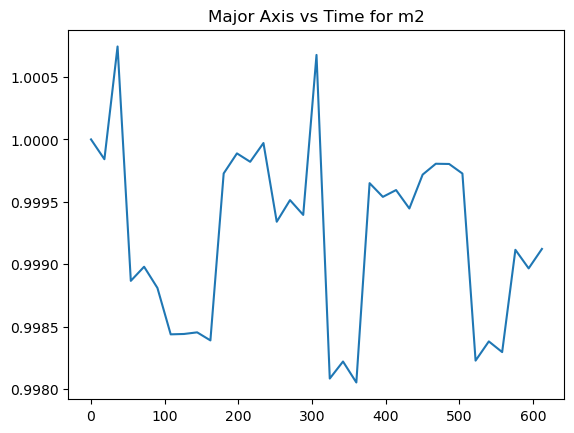

In [44]:
plt.plot(t,a2)
plt.title("Major Axis vs Time for m2")
plt.show()

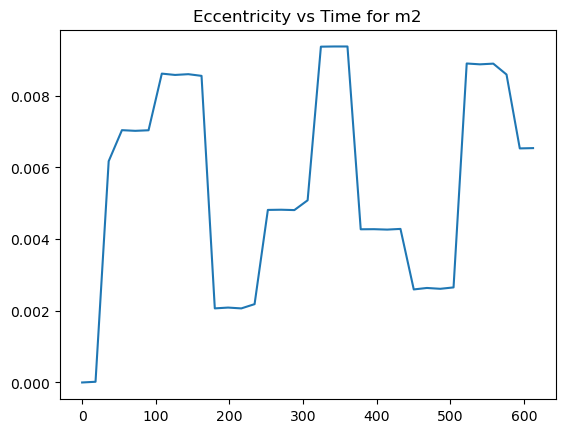

In [41]:
plt.plot(t,e2)
plt.title("Eccentricity vs Time for m2")
plt.show()

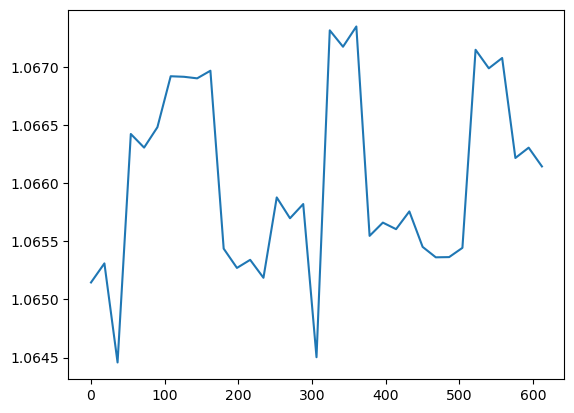

In [42]:
plt.plot(t,a3)
plt.show()

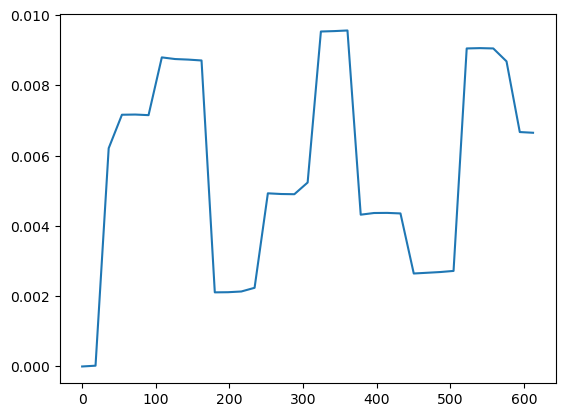

In [43]:
plt.plot(t,e3)
plt.show()

In [39]:
sim2 = rebound.Simulation()

sim2.integrator = "IAS15"

def boom(sim_pointer,collision):
    global cnt
    sim = sim_pointer.contents
    print(sim.t)
    cnt += 1
    return 0

cnt = 0
sim2.collision = "direct"
sim2.collision_resolve = boom

m2=m3=1e-5

r_hill = (m2 / 3.0)**(1./3)

delta_c = 2.4*(m2 + m3)**(1./3)

delta = 1*delta_c

sim2.add(m=1)
sim2.add(m=m2,a = 1,r=r_hill,e=0)
sim2.add(m=m3,a = 1 + delta,r=r_hill,omega=np.pi,e=0)

sim2.move_to_com()

sim2.save_to_file("problem_2_data.bin", interval = 18, delete_file = True)

sim2.integrate(2*np.pi*1e2)

snaps = rebound.Simulationarchive("problem_2_data.bin")

a2 = [snap.particles[1].a for snap in snaps]
e2 = [snap.particles[1].e for snap in snaps]
a3 = [snap.particles[2].a for snap in snaps]
e3 = [snap.particles[2].e for snap in snaps]
t = [snap.t for snap in snaps]

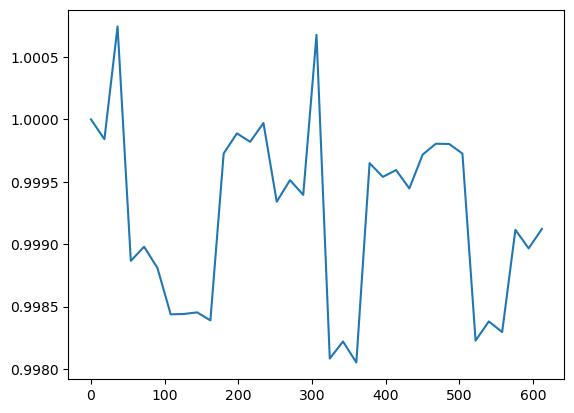

In [29]:
plt.plot(t,a2)
plt.show()

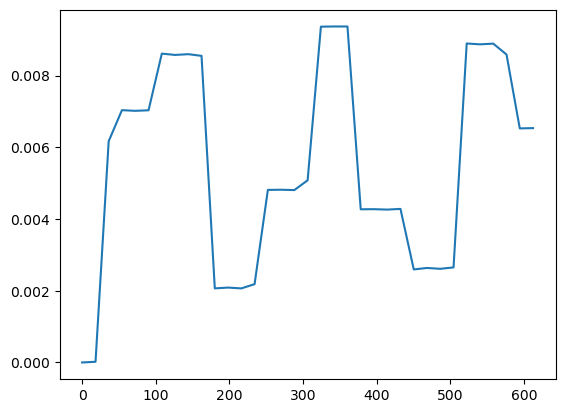

In [30]:
plt.plot(t,e2)

In [37]:
sim2 = rebound.Simulation()

sim2.integrator = "IAS15"

def boom(sim_pointer,collision):
    global cnt
    sim = sim_pointer.contents
    print(sim.t)
    cnt += 1
    return 0

cnt = 0
sim2.collision = "direct"
sim2.collision_resolve = boom

m2=m3=1e-5

r_hill = (m2 / 3.0)**(1./3)

delta_c = 2.4*(m2 + m3)**(1./3)

delta = 10*delta_c

sim2.add(m=1)
sim2.add(m=m2,a = 1,r=r_hill,e=0)
sim2.add(m=m3,a = 1 + delta,r=r_hill,omega=np.pi,e=0)

sim2.move_to_com()

sim2.save_to_file("problem_2_data.bin", interval = 18, delete_file = True)

sim2.integrate(2*np.pi*1e2)

snaps = rebound.Simulationarchive("problem_2_data.bin")

a2 = [snap.particles[1].a for snap in snaps]
e2 = [snap.particles[1].e for snap in snaps]
a3 = [snap.particles[2].a for snap in snaps]
e3 = [snap.particles[2].e for snap in snaps]
t = [snap.t for snap in snaps]

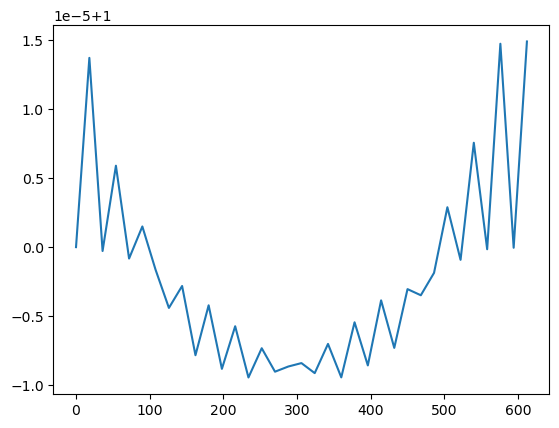

In [38]:
plt.plot(t,a2)

In [34]:
print(f"Number of particles: {sim2.N}")

Number of particles: 3


In [45]:
sim2 = rebound.Simulation()

sim2.integrator = "IAS15"

def boom(sim_pointer,collision):
    global cnt
    sim = sim_pointer.contents
    print(sim.t)
    cnt += 1
    return 0

cnt = 0
sim2.collision = "direct"
sim2.collision_resolve = boom

m2=m3=1e-5

r_hill = (m2 / 3.0)**(1./3)

delta_c = 2.4*(m2 + m3)**(1./3)

delta = 100*delta_c

sim2.add(m=1)
sim2.add(m=m2,a = 1,r=r_hill,e=0)
sim2.add(m=m3,a = 1 + delta,r=r_hill,omega=np.pi,e=0)

sim2.move_to_com()

sim2.save_to_file("problem_2_data.bin", interval = 18, delete_file = True)

sim2.integrate(2*np.pi*1e2)

snaps = rebound.Simulationarchive("problem_2_data.bin")

a2 = [snap.particles[1].a for snap in snaps]
e2 = [snap.particles[1].e for snap in snaps]
a3 = [snap.particles[2].a for snap in snaps]
e3 = [snap.particles[2].e for snap in snaps]
t = [snap.t for snap in snaps]

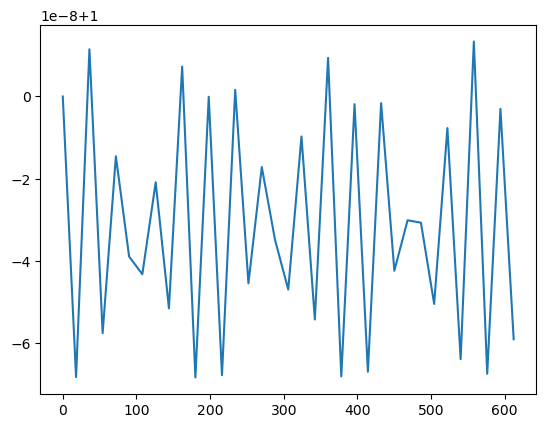

In [46]:
plt.plot(t,a2)

In [48]:
sim2 = rebound.Simulation()

sim2.integrator = "IAS15"

def boom(sim_pointer,collision):
    global cnt
    sim = sim_pointer.contents
    print(sim.t)
    cnt += 1
    return 0

cnt = 0
sim2.collision = "direct"
sim2.collision_resolve = boom

m2=m3=1e-5

r_hill = (m2 / 3.0)**(1./3)

delta_c = 2.4*(m2 + m3)**(1./3)

delta = 0.5*delta_c

sim2.add(m=1)
sim2.add(m=m2,a = 1,r=r_hill,e=0)
sim2.add(m=m3,a = 1 + delta,r=r_hill,omega=np.pi,e=0)

sim2.move_to_com()

sim2.save_to_file("problem_2_data.bin", interval = 18, delete_file = True)

sim2.integrate(2*np.pi*1e2)

snaps = rebound.Simulationarchive("problem_2_data.bin")

a2 = [snap.particles[1].a for snap in snaps]
e2 = [snap.particles[1].e for snap in snaps]
a3 = [snap.particles[2].a for snap in snaps]
e3 = [snap.particles[2].e for snap in snaps]
t = [snap.t for snap in snaps]

66.6779247427657
66.6779247427657
66.85351892455063
66.85351892455063
67.01942349118634
67.01942349118634
67.16903701105987
67.16903701105987


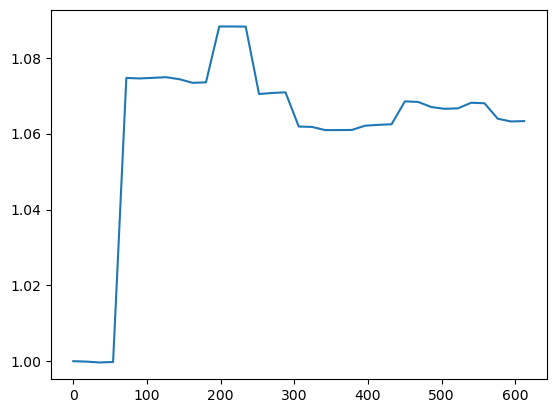

In [49]:
plt.plot(t,a2)

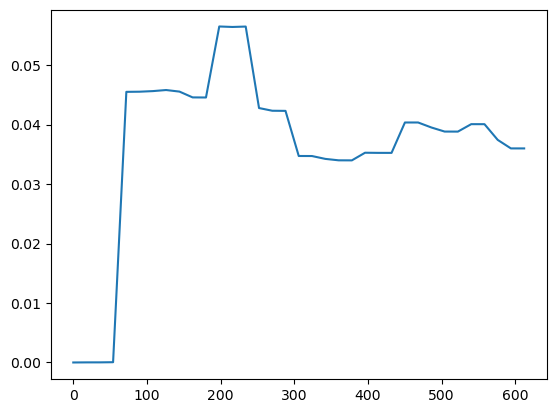

In [50]:
plt.plot(t,e2)
plt.show()

In [1]:
#problem 3 Jupiter and Kirkwood gaps
''' from NASA horizons 
Mars:
2461046.500000000 = A.D. 2026-Jan-06 00:00:00.0000 TDB 
 X = 4.107132905782458E-01 Y =-1.362545442466922E+00 Z =-3.862449818410463E-02
 VX= 1.392773010292962E-02 VY= 5.241593832593102E-03 VZ=-2.316860675084084E-04
 LT= 8.222170664018537E-03 RG= 1.423624719406404E+00 RR=-9.922960381706506E-04

Jupiter:
2461046.500000000 = A.D. 2026-Jan-06 00:00:00.0000 TDB 
 X =-1.730110530239572E+00 Y = 4.918246936250828E+00 Z = 1.827832043237462E-02
 VX=-7.213472832140575E-03 VY=-2.152537221387144E-03 VZ= 1.703221733472269E-04
 LT= 3.011187629824982E-02 RG= 5.213709760792629E+00 RR= 3.637542177267547E-04
'''

' from NASA horizons \nMars:\n2461046.500000000 = A.D. 2026-Jan-06 00:00:00.0000 TDB \n X = 4.107132905782458E-01 Y =-1.362545442466922E+00 Z =-3.862449818410463E-02\n VX= 1.392773010292962E-02 VY= 5.241593832593102E-03 VZ=-2.316860675084084E-04\n LT= 8.222170664018537E-03 RG= 1.423624719406404E+00 RR=-9.922960381706506E-04\n\nJupiter:\n2461046.500000000 = A.D. 2026-Jan-06 00:00:00.0000 TDB \n X =-1.730110530239572E+00 Y = 4.918246936250828E+00 Z = 1.827832043237462E-02\n VX=-7.213472832140575E-03 VY=-2.152537221387144E-03 VZ= 1.703221733472269E-04\n LT= 3.011187629824982E-02 RG= 5.213709760792629E+00 RR= 3.637542177267547E-04\n'

In [41]:
sim3 = rebound.Simulation()

sim3.units = ('day', 'AU', 'Msun')

sim3.add(m=1)
sim3.add(m=3.2e-7,x=4.11e-7,y=-1.36,z=-3.862e-2,vx=1.39e-2,vy=5.24e-3,vz=-2.32e-4,hash="Mars")
sim3.add(m=9.54e-4,x=-1.73,y=4.92,z=1.83e-2,vx=-7.21e-3,vy=-2.15e-3,vz=1.7e-4,hash="Jupiter")

sim3.N_active = 3

#atroid_a = np.linspace(2,4,100)
#for i in atroid_a:
    #sim3.add(a=i,f=np.random.rand()*2*np.pi,e=np.random.rand()*0.5)

for i in range(50):
    sim3.add(a=2.5,f=np.random.rand()*2*np.pi,e=0)

for j in range(50):
    sim3.add(a=2.3,f=np.random.rand()*2*np.pi,e=0)

solarmass = 1.989e30
au = 1.496e11
gravitationalconstant = 6.67408e-11

orbit = 2* np.pi*np. sqrt (8* au*au*au /( gravitationalconstant * solarmass ) ) ;
sim3.dt = orbit *1e-2

sim3.integrate(500000)
    

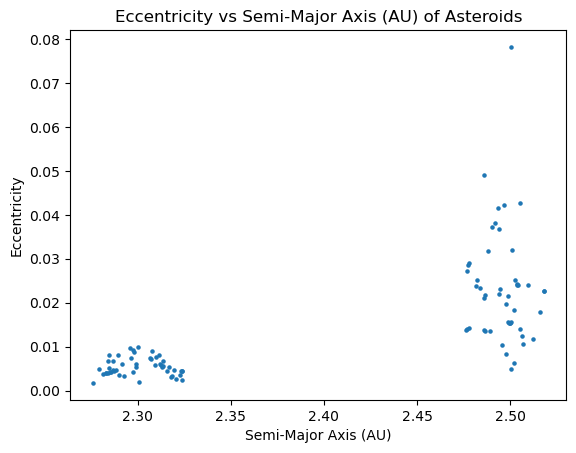

In [51]:
atr_a = np.zeros(100)
atr_e = np.zeros(100)

for i in range(3,103):
    atr_a[i-3] = sim3.particles[i].a
    atr_e[i-3] = sim3.particles[i].e
plt.scatter(atr_a,atr_e,s=5)
plt.title("Eccentricity vs Semi-Major Axis (AU) of Asteroids")
plt.xlabel("Semi-Major Axis (AU)")
plt.ylabel("Eccentricity")
plt.show()

In [16]:
#problem 4, resonant capture of a planet
sim4 = rebound.Simulation()
sim4.integrator = "whfast"
sim4.units = ("yr","AU","Msun")
sim4.add(m=1)
sim4.add(m=5.1e-5, a=24., e=0.01, hash="neptune")
sim4.add(m=3e-6 , a=10. , e=0.0 , hash ="planet")
sim4.move_to_com()

sim4.dt = 0.05 * sim4.particles["planet"].P

rebx = reboundx.Extras(sim4)
mod_eff = rebx.load_force("exponential_migration")
rebx.add_force(mod_eff)

sim4.particles[1].params["em_aini"] = 24. 
sim4.particles[1].params["em_afin"] = 10.  
sim4.particles[1].params["em_tau_a"] = 1e7

sim4.save_to_file("problem_4_data.bin", interval = 1000, delete_file = True)

sim4.integrate(1e7)

snaps = rebound.Simulationarchive("problem_4_data.bin")

a_n = np.array([snap.particles[1].a for snap in snaps])
e_n = np.array([snap.particles[1].e for snap in snaps])
P_n = np.array([snap.particles[1].P for snap in snaps])
a_p = np.array([snap.particles[2].a for snap in snaps])
e_p = np.array([snap.particles[2].e for snap in snaps])
P_p = np.array([snap.particles[2].P for snap in snaps])
t = np.array([snap.t for snap in snaps])

/home/miaed/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/rebound/simulation.py:259: RuntimeWarning: REBOUNDx: Passing a velocity-dependent force to WHFAST. Need to apply as an operator. See REBOUNDx paper sec 5.1.
  warnings.warn(msg[1:], RuntimeWarning)


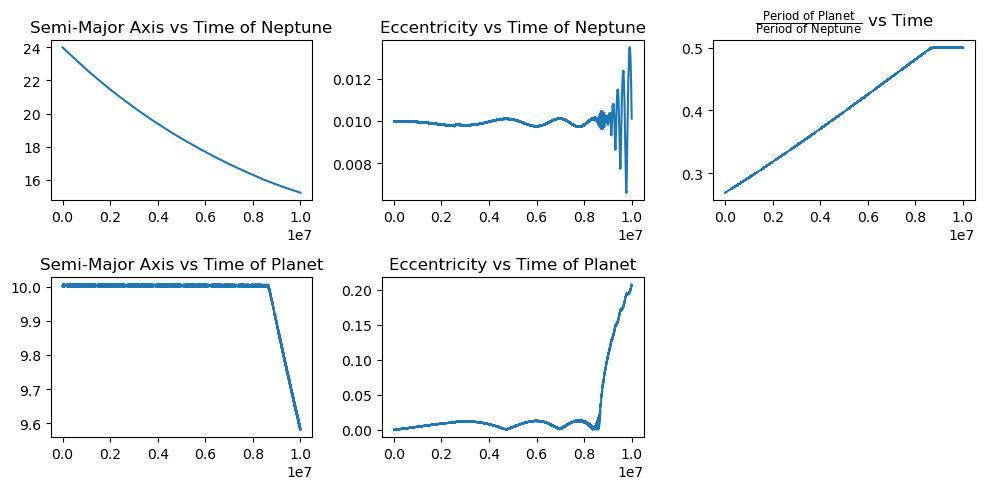

In [17]:
fig,axs = plt.subplots(2,3, figsize = (10,5))
axs[0,0].plot(t,a_n)
axs[0,0].set_title("Semi-Major Axis vs Time of Neptune")
axs[0,1].plot(t,e_n)
axs[0,1].set_title("Eccentricity vs Time of Neptune")
axs[0,2].plot(t,P_p/P_n)
axs[0,2].set_title(r"$\frac{\text{Period of Planet}}{\text{Period of Neptune}}$ vs Time")
axs[1,0].plot(t,a_p)
axs[1,0].set_title("Semi-Major Axis vs Time of Planet")
axs[1,1].plot(t,e_p)
axs[1,1].set_title("Eccentricity vs Time of Planet")
axs[1,2].set_visible(False)
plt.tight_layout()
plt.show()